In [ ]:
!pip install torch torchvision torchaudio -q
!pip install open3d tqdm wandb huggingface_hub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.0 MB/s eta 0:00:00


In [ ]:
import os, glob, zipfile, random, math

import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import wandb
from huggingface_hub import hf_hub_download

In [ ]:
CFG = {
    # data
    "data_dir":    "data/MaizeField",
    "num_points":  1024,
    "batch_size":  8,

    # training
    "epochs":        200,
    "lr":            3e-4,
    "warmup_epochs": 10,
    "grad_clip":     1.0,    # gradient clipping max norm
    "patience":      20,     # early stopping patience (epochs without val improvement)

    # architecture
    "latent_dim":  256,
    "num_heads":   4,
    "enc_layers":  4,
    "dec_layers":  6,
    "ff_dim":      1024,
    "dropout":     0.1,

    # misc
    "train_plants":        500,
    "val_plants":          200,
    "test_plants":         300,
    "checkpoint_interval": 10,
    "seed":                42,
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [ ]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shantanugupta2004 (shantanugupta2004-own-use) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
wandb.init(
    project="maizefield-transformer-ae-log",
    config=CFG,
)

In [ ]:
os.makedirs("data", exist_ok=True)

zip_path = hf_hub_download(
    repo_id="BGLab/MaizeField3D",
    filename="datasets/FielGrwon_ZeaMays_RawPCD_10k.zip",
    repo_type="dataset",
    local_dir="data",
)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(CFG["data_dir"])

ply_files = sorted(glob.glob(f"{CFG['data_dir']}/**/*.ply", recursive=True))
print("Total plants:", len(ply_files))

Total plants: 1045


In [ ]:
random.seed(CFG["seed"])
random.shuffle(ply_files)

train_files = ply_files[:CFG["train_plants"]]
val_files   = ply_files[CFG["train_plants"]: CFG["train_plants"] + CFG["val_plants"]]
test_files  = ply_files[CFG["train_plants"] + CFG["val_plants"]:
                        CFG["train_plants"] + CFG["val_plants"] + CFG["test_plants"]]

print("Train:", len(train_files), "| Val:", len(val_files), "| Test:", len(test_files))

Train: 500 | Val: 200 | Test: 300


In [ ]:
def normalize_pc(pc):
    pc = pc - pc.mean(axis=0)
    scale = np.sqrt((pc ** 2).sum(axis=1)).max()
    return pc / scale


class MaizeDataset(Dataset):
    def __init__(self, files, augment=False):
        self.files   = files
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        pcd    = o3d.io.read_point_cloud(self.files[idx])
        points = np.asarray(pcd.points, dtype=np.float32)
        points = normalize_pc(points)
        chosen = np.random.choice(len(points), CFG["num_points"], replace=False)
        points = points[chosen]

        if self.augment:
            # Random jitter — small Gaussian noise on each point
            points += np.random.normal(0, 0.01, points.shape).astype(np.float32)
            # Random scale in [0.9, 1.1]
            points *= np.random.uniform(0.9, 1.1)
            # Random rotation around Z axis (plant upright axis)
            angle = np.random.uniform(-np.pi/6, np.pi/6)
            c, s  = np.cos(angle), np.sin(angle)
            Rz    = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float32)
            points = points @ Rz.T

        return torch.from_numpy(points)

In [ ]:
train_dataset = MaizeDataset(train_files, augment=True)   # ← augment only train
val_dataset   = MaizeDataset(val_files,   augment=False)
test_dataset  = MaizeDataset(test_files,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

## Model — Transformer Autoencoder

In [ ]:
# ──────────────────────────────────────────────────────────────
#  Transformer Point-Cloud Autoencoder
#
#  Encoder
#  -------
#  1. Per-point linear embedding  (3 → latent_dim)
#  2. Sinusoidal positional encoding over point index
#  3. N Transformer encoder layers
#  4. Global average pool  →  latent vector  (latent_dim,)
#
#  Decoder
#  -------
#  1. Learned query tokens  (num_points × latent_dim)
#  2. N Transformer decoder layers cross-attending to the latent
#  3. Per-token linear head  →  xyz  (num_points × 3)
# ──────────────────────────────────────────────────────────────

class SinusoidalPE(nn.Module):
    """Learnable-free positional encoding over sequence position."""
    def __init__(self, d_model: int, max_len: int = 2048):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):                             # x: (B, N, D)
        return x + self.pe[:, :x.size(1)]


class TransformerEncoder(nn.Module):
    def __init__(self, latent_dim, num_heads, num_layers, ff_dim, dropout):
        super().__init__()
        self.embed = nn.Linear(3, latent_dim)
        self.pe    = SinusoidalPE(latent_dim, max_len=2048)
        layer = nn.TransformerEncoderLayer(
            d_model=latent_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=True,   # Pre-LN: more stable training
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers,
                                                 enable_nested_tensor=False)
        self.norm = nn.LayerNorm(latent_dim)

    def forward(self, x):                    # x: (B, N, 3)
        x = self.embed(x)                    # (B, N, D)
        x = self.pe(x)
        x = self.transformer(x)              # (B, N, D)
        x = self.norm(x)
        latent = x.mean(dim=1)              # (B, D)  — global avg pool
        return latent


class TransformerDecoder(nn.Module):
    def __init__(self, latent_dim, num_points, num_heads, num_layers, ff_dim, dropout):
        super().__init__()
        self.num_points = num_points

        # Learned query tokens — larger init so they don't collapse
        self.query_tokens = nn.Parameter(torch.randn(1, num_points, latent_dim) * 0.1)

        # Positional encoding on queries so each token has a unique identity
        self.query_pe = SinusoidalPE(latent_dim, max_len=num_points)

        # Project latent → sequence of 4 tokens (richer memory signal)
        self.latent_proj = nn.Linear(latent_dim, 4 * latent_dim)

        layer = nn.TransformerDecoderLayer(
            d_model=latent_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerDecoder(layer, num_layers=num_layers)
        self.norm   = nn.LayerNorm(latent_dim)
        self.to_xyz = nn.Linear(latent_dim, 3)

    def forward(self, latent):               # latent: (B, D)
        B = latent.size(0)

        # Expand latent into 4 memory tokens instead of 1
        memory = self.latent_proj(latent)            # (B, 4*D)
        memory = memory.view(B, 4, -1)               # (B, 4, D)

        # Add positional encoding to queries so they diverge
        queries = self.query_tokens.expand(B, -1, -1)  # (B, N, D)
        queries = self.query_pe(queries)

        out = self.transformer(queries, memory)
        out = self.norm(out)
        return self.to_xyz(out)                        # (B, N, 3)


class TransformerAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = TransformerEncoder(
            latent_dim=cfg["latent_dim"],
            num_heads=cfg["num_heads"],
            num_layers=cfg["enc_layers"],
            ff_dim=cfg["ff_dim"],
            dropout=cfg["dropout"],
        )
        self.decoder = TransformerDecoder(
            latent_dim=cfg["latent_dim"],
            num_points=cfg["num_points"],
            num_heads=cfg["num_heads"],
            num_layers=cfg["dec_layers"],
            ff_dim=cfg["ff_dim"],
            dropout=cfg["dropout"],
        )

    def forward(self, x):                    # x: (B, N, 3)
        latent = self.encoder(x)
        recon  = self.decoder(latent)
        return recon


model = TransformerAE(CFG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {n_params:,}")

Parameters: 10,007,811


In [ ]:
def chamfer_loss(pc1, pc2, density_weight=0.5):
    dist = torch.cdist(pc1, pc2, p=2).pow(2)   # (B, N, N)

    d1 = dist.min(dim=2)[0]
    d2 = dist.min(dim=1)[0]

    with torch.no_grad():
        knn_dist = torch.cdist(pc1, pc1, p=2)   # (B, N, N)
        # mask diagonal per batch item instead of fill_diagonal_
        B, N, _ = knn_dist.shape
        eye = torch.eye(N, device=pc1.device, dtype=torch.bool).unsqueeze(0)  # (1, N, N)
        knn_dist = knn_dist.masked_fill(eye, float('inf'))

        sparse_weight = knn_dist.topk(5, dim=2, largest=False)[0].mean(dim=2)
        sparse_weight = sparse_weight / (sparse_weight.mean(dim=1, keepdim=True) + 1e-8)
        sparse_weight = 1.0 + density_weight * sparse_weight

    loss1 = (d1 * sparse_weight).mean()
    loss2 = d2.mean()
    return loss1 + loss2

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=1e-4)

# Cosine annealing with linear warm-up
def lr_lambda(epoch):
    wu = CFG["warmup_epochs"]
    if epoch < wu:
        return (epoch + 1) / wu            # linear warm-up
    progress = (epoch - wu) / max(1, CFG["epochs"] - wu)
    return 0.5 * (1.0 + math.cos(math.pi * progress))   # cosine decay

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [ ]:
def evaluate(model, loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for pc in loader:
            pc = pc.to(DEVICE)
            recon = model(pc)
            total += chamfer_loss(pc, recon).item()
    return total / len(loader)

In [ ]:
def visualize_reconstruction(model, dataset, title_suffix=""):
    model.eval()
    idx = np.random.randint(len(dataset))
    pc  = dataset[idx].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        recon = model(pc)

    pc    = pc.squeeze().cpu().numpy()
    recon = recon.squeeze().cpu().numpy()

    fig = plt.figure(figsize=(12, 5), facecolor="#111111")

    for ax_idx, (pts, label) in enumerate([(pc, "Original"), (recon, "Reconstruction")]):
        ax = fig.add_subplot(1, 2, ax_idx + 1, projection="3d")
        ax.set_facecolor("#111111")
        ax.scatter(pts[:, 0], pts[:, 2], pts[:, 1],
                   s=1.5, c=pts[:, 1], cmap="plasma", alpha=0.8)
        ax.set_title(f"{label}{title_suffix}", color="white", fontsize=12)
        ax.tick_params(colors="white")
        for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
            pane.fill = False
        ax.grid(False)

    plt.tight_layout()
    plt.show()       # ← prints inline in the notebook
    return fig

## Training

Epoch 000: 100%|██████████| 63/63 [00:26<00:00,  2.34it/s]


Epoch 000  train 0.04326  val 0.03108  lr 6.00e-05
  ✅ New best val loss: 0.03108 — saved best_model.pth


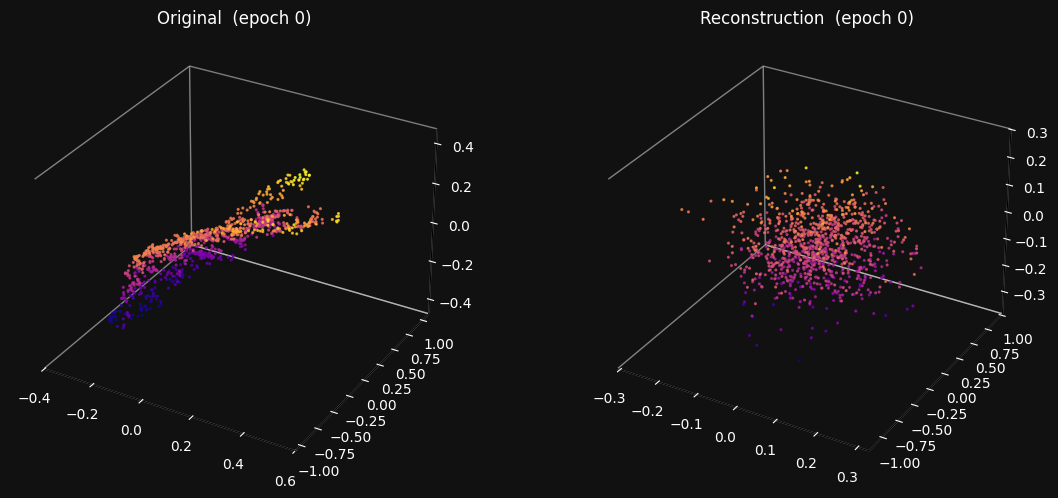

Epoch 001: 100%|██████████| 63/63 [00:24<00:00,  2.57it/s]


Epoch 001  train 0.02569  val 0.02810  lr 9.00e-05
  ✅ New best val loss: 0.02810 — saved best_model.pth


Epoch 002: 100%|██████████| 63/63 [00:24<00:00,  2.58it/s]


Epoch 002  train 0.02898  val 0.02346  lr 1.20e-04
  ✅ New best val loss: 0.02346 — saved best_model.pth


Epoch 003: 100%|██████████| 63/63 [00:24<00:00,  2.53it/s]


...

Epoch 008  train 0.02146  val 0.02000  lr 3.00e-04
  ✅ New best val loss: 0.02000 — saved best_model.pth


Epoch 009: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 009  train 0.02160  val 0.02149  lr 3.00e-04


Epoch 010: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 010  train 0.02162  val 0.01935  lr 3.00e-04
  ✅ New best val loss: 0.01935 — saved best_model.pth


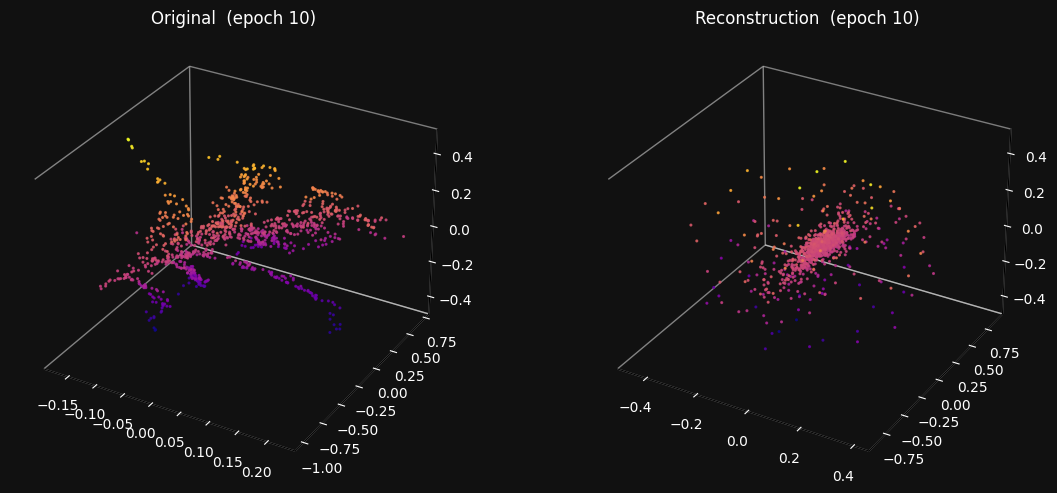

Epoch 011: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 011  train 0.02083  val 0.02021  lr 3.00e-04


Epoch 012: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 012  train 0.02052  val 0.01887  lr 3.00e-04
  ✅ New best val loss: 0.01887 — saved best_model.pth


Epoch 013: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


...

Epoch 018  train 0.01194  val 0.01121  lr 2.98e-04
  ✅ New best val loss: 0.01121 — saved best_model.pth


Epoch 019: 100%|██████████| 63/63 [00:24<00:00,  2.54it/s]


Epoch 019  train 0.01132  val 0.01145  lr 2.98e-04


Epoch 020: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 020  train 0.01081  val 0.01148  lr 2.98e-04


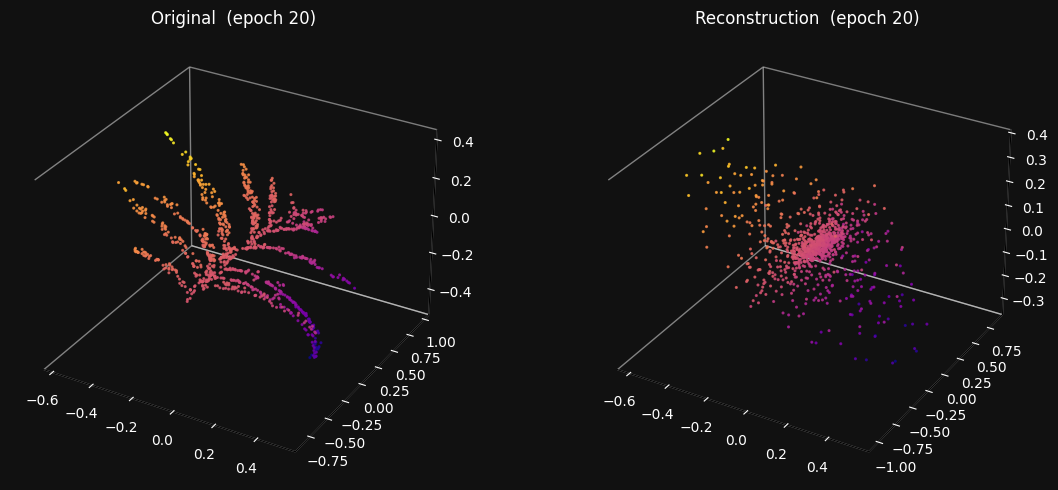

Epoch 021: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 021  train 0.01000  val 0.00985  lr 2.97e-04
  ✅ New best val loss: 0.00985 — saved best_model.pth


Epoch 022: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 022  train 0.00998  val 0.01027  lr 2.97e-04


Epoch 023: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


...

Epoch 028  train 0.00918  val 0.00957  lr 2.93e-04


Epoch 029: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 029  train 0.00878  val 0.00874  lr 2.92e-04
  ✅ New best val loss: 0.00874 — saved best_model.pth


Epoch 030: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 030  train 0.00851  val 0.00887  lr 2.91e-04


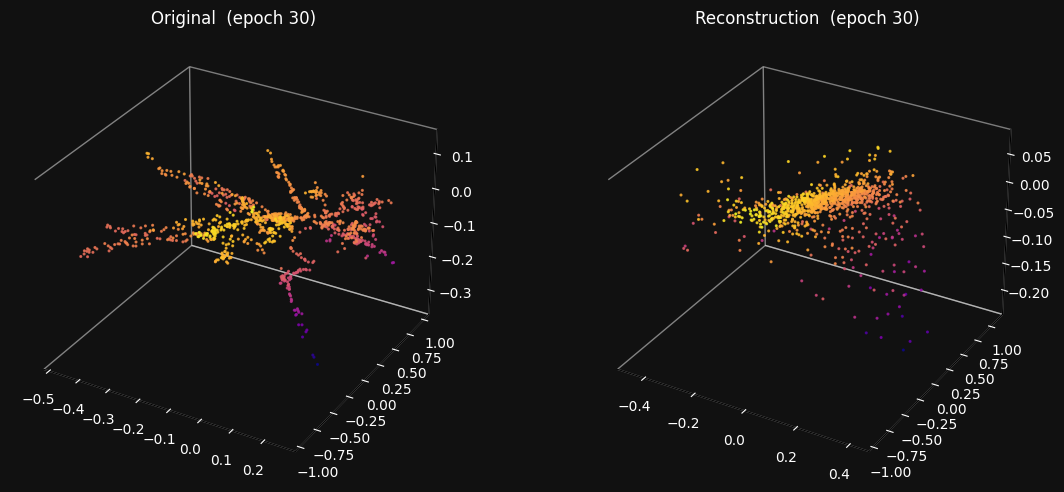

Epoch 031: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 031  train 0.00861  val 0.00857  lr 2.90e-04
  ✅ New best val loss: 0.00857 — saved best_model.pth


Epoch 032: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 032  train 0.00803  val 0.00799  lr 2.89e-04
  ✅ New best val loss: 0.00799 — saved best_model.pth


Epoch 033: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


...

Epoch 038  train 0.00761  val 0.00787  lr 2.83e-04


Epoch 039: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 039  train 0.00766  val 0.00776  lr 2.82e-04
  ✅ New best val loss: 0.00776 — saved best_model.pth


Epoch 040: 100%|██████████| 63/63 [00:24<00:00,  2.54it/s]


Epoch 040  train 0.00749  val 0.00834  lr 2.81e-04


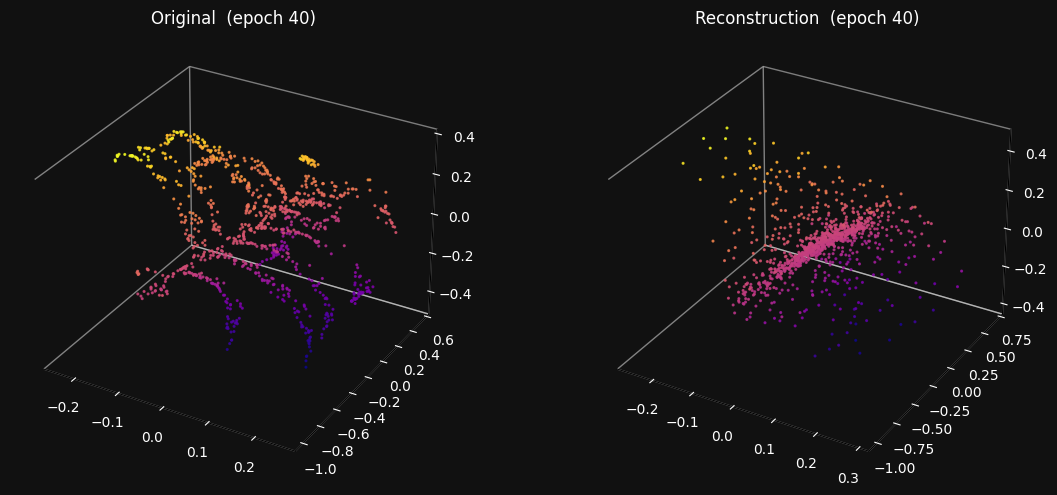

Epoch 041: 100%|██████████| 63/63 [00:24<00:00,  2.54it/s]


Epoch 041  train 0.00752  val 0.00812  lr 2.79e-04


Epoch 042: 100%|██████████| 63/63 [00:24<00:00,  2.54it/s]


Epoch 042  train 0.00775  val 0.00752  lr 2.78e-04
  ✅ New best val loss: 0.00752 — saved best_model.pth


Epoch 043: 100%|██████████| 63/63 [00:24<00:00,  2.54it/s]


...

Epoch 048  train 0.00712  val 0.00738  lr 2.70e-04
  ✅ New best val loss: 0.00738 — saved best_model.pth


Epoch 049: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 049  train 0.00711  val 0.00730  lr 2.68e-04
  ✅ New best val loss: 0.00730 — saved best_model.pth


Epoch 050: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 050  train 0.00680  val 0.00734  lr 2.67e-04


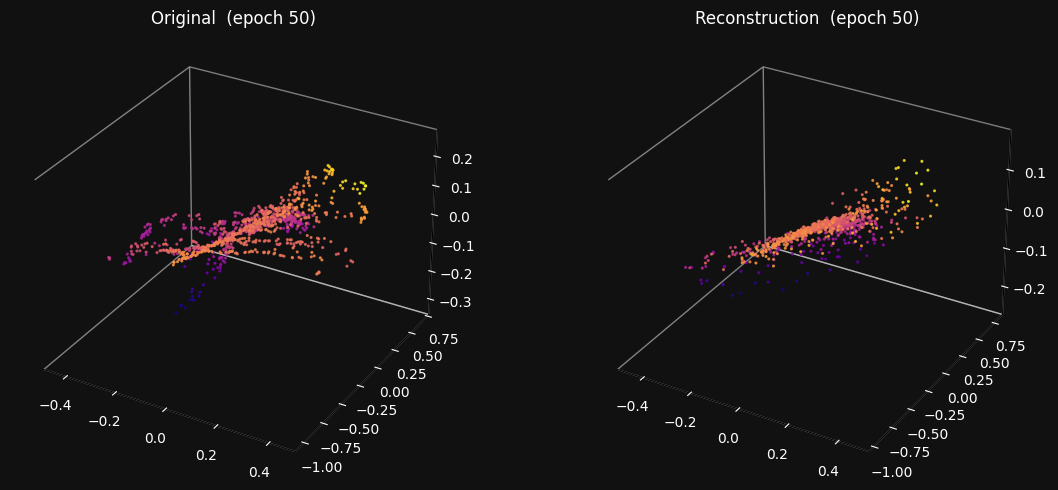

Epoch 051: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 051  train 0.00680  val 0.00742  lr 2.65e-04


Epoch 052: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 052  train 0.00709  val 0.00740  lr 2.64e-04


Epoch 053: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


...

Epoch 058  train 0.00662  val 0.00691  lr 2.53e-04
  ✅ New best val loss: 0.00691 — saved best_model.pth


Epoch 059: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 059  train 0.00668  val 0.00718  lr 2.52e-04


Epoch 060: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 060  train 0.00672  val 0.00707  lr 2.50e-04


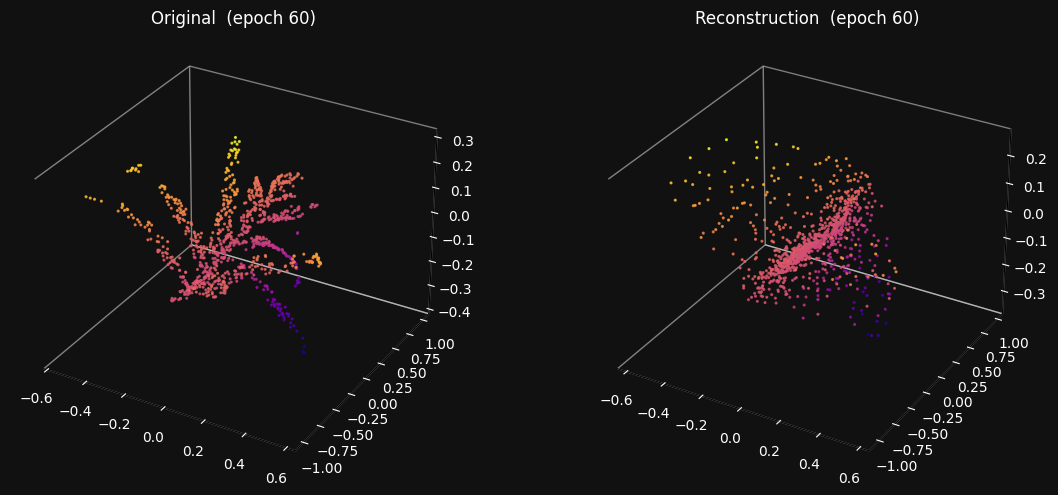

Epoch 061: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 061  train 0.00660  val 0.00687  lr 2.48e-04
  ✅ New best val loss: 0.00687 — saved best_model.pth


Epoch 062: 100%|██████████| 63/63 [00:24<00:00,  2.54it/s]


Epoch 062  train 0.00660  val 0.00701  lr 2.46e-04


Epoch 063: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


...

Epoch 068  train 0.00647  val 0.00659  lr 2.34e-04
  ✅ New best val loss: 0.00659 — saved best_model.pth


Epoch 069: 100%|██████████| 63/63 [00:24<00:00,  2.54it/s]


Epoch 069  train 0.00627  val 0.00675  lr 2.32e-04


Epoch 070: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 070  train 0.00615  val 0.00660  lr 2.30e-04


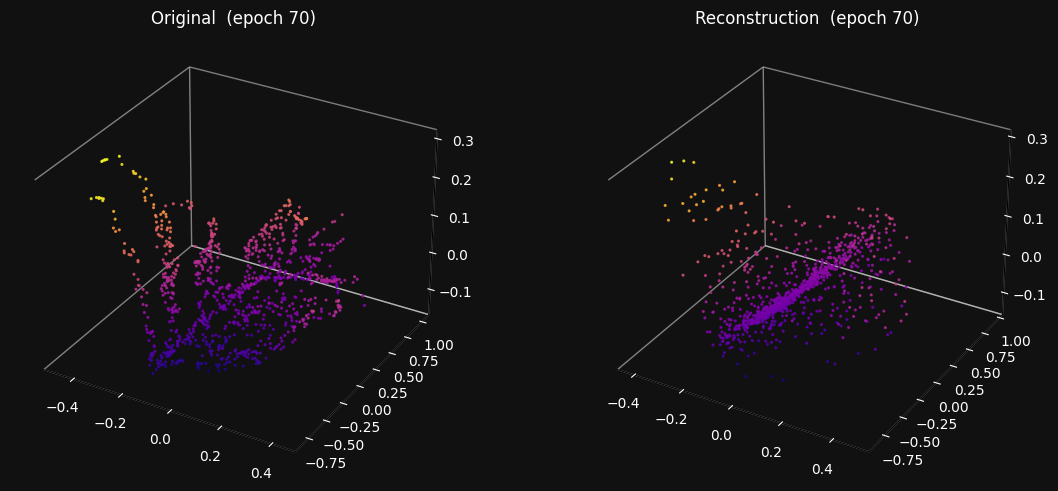

Epoch 071: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 071  train 0.00603  val 0.00630  lr 2.28e-04
  ✅ New best val loss: 0.00630 — saved best_model.pth


Epoch 072: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 072  train 0.00591  val 0.00630  lr 2.26e-04


Epoch 073: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


...

Epoch 078  train 0.00589  val 0.00643  lr 2.13e-04


Epoch 079: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 079  train 0.00591  val 0.00647  lr 2.10e-04


Epoch 080: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 080  train 0.00590  val 0.00623  lr 2.08e-04
  ✅ New best val loss: 0.00623 — saved best_model.pth


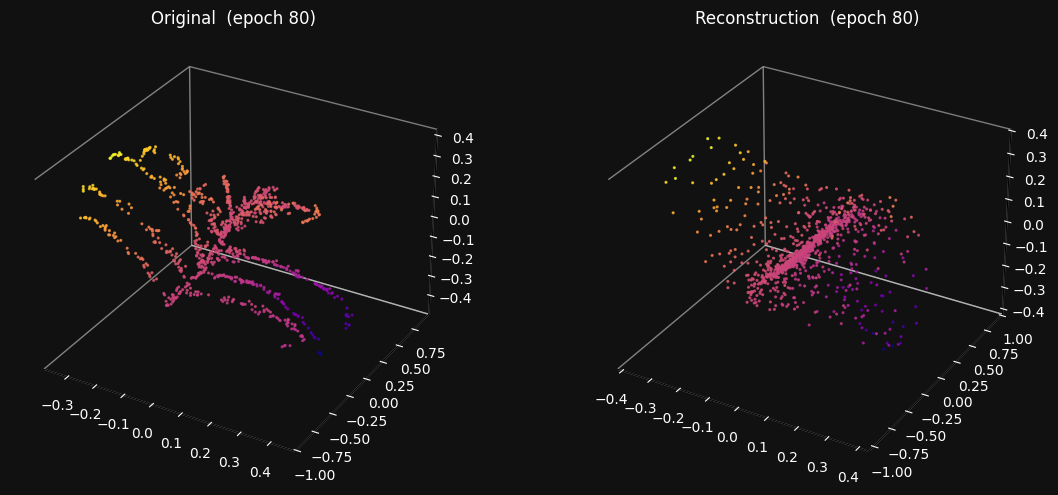

Epoch 081: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 081  train 0.00579  val 0.00620  lr 2.06e-04
  ✅ New best val loss: 0.00620 — saved best_model.pth


Epoch 082: 100%|██████████| 63/63 [00:24<00:00,  2.54it/s]


Epoch 082  train 0.00575  val 0.00632  lr 2.03e-04


Epoch 083: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


...

Epoch 088  train 0.00557  val 0.00616  lr 1.89e-04


Epoch 089: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 089  train 0.00562  val 0.00600  lr 1.87e-04
  ✅ New best val loss: 0.00600 — saved best_model.pth


Epoch 090: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 090  train 0.00551  val 0.00584  lr 1.84e-04
  ✅ New best val loss: 0.00584 — saved best_model.pth


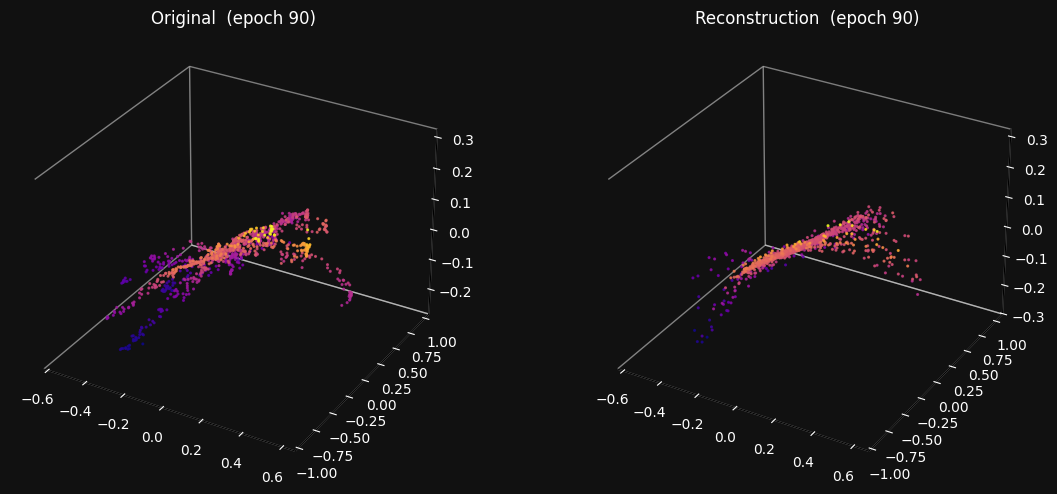

Epoch 091: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 091  train 0.00554  val 0.00611  lr 1.82e-04


Epoch 092: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 092  train 0.00553  val 0.00615  lr 1.80e-04


Epoch 093: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


...

Epoch 098  train 0.00538  val 0.00596  lr 1.65e-04


Epoch 099: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 099  train 0.00529  val 0.00574  lr 1.62e-04
  ✅ New best val loss: 0.00574 — saved best_model.pth


Epoch 100: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 100  train 0.00528  val 0.00584  lr 1.60e-04


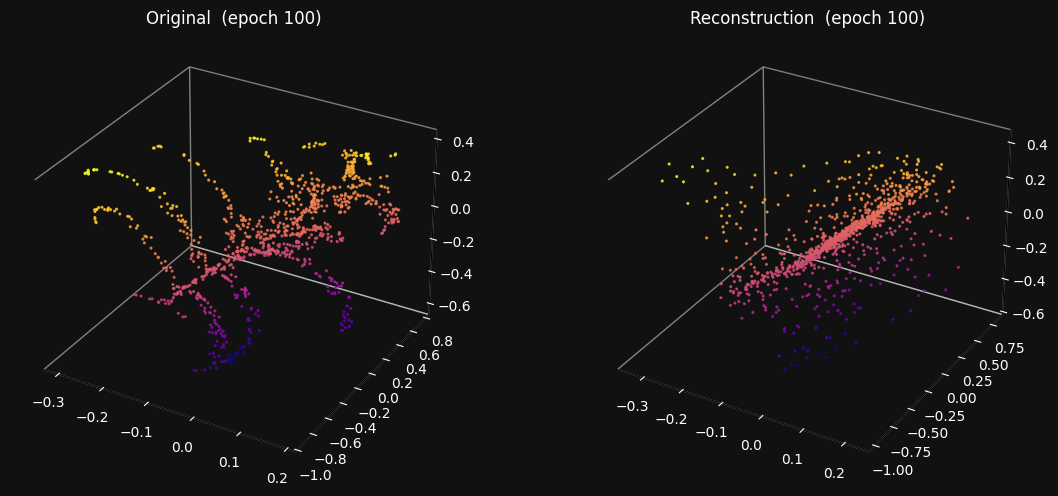

Epoch 101: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 101  train 0.00528  val 0.00569  lr 1.57e-04
  ✅ New best val loss: 0.00569 — saved best_model.pth


Epoch 102: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 102  train 0.00520  val 0.00592  lr 1.55e-04


Epoch 103: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


...

Epoch 108  train 0.00512  val 0.00570  lr 1.40e-04


Epoch 109: 100%|██████████| 63/63 [00:24<00:00,  2.54it/s]


Epoch 109  train 0.00512  val 0.00561  lr 1.38e-04
  ✅ New best val loss: 0.00561 — saved best_model.pth


Epoch 110: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 110  train 0.00504  val 0.00554  lr 1.35e-04
  ✅ New best val loss: 0.00554 — saved best_model.pth


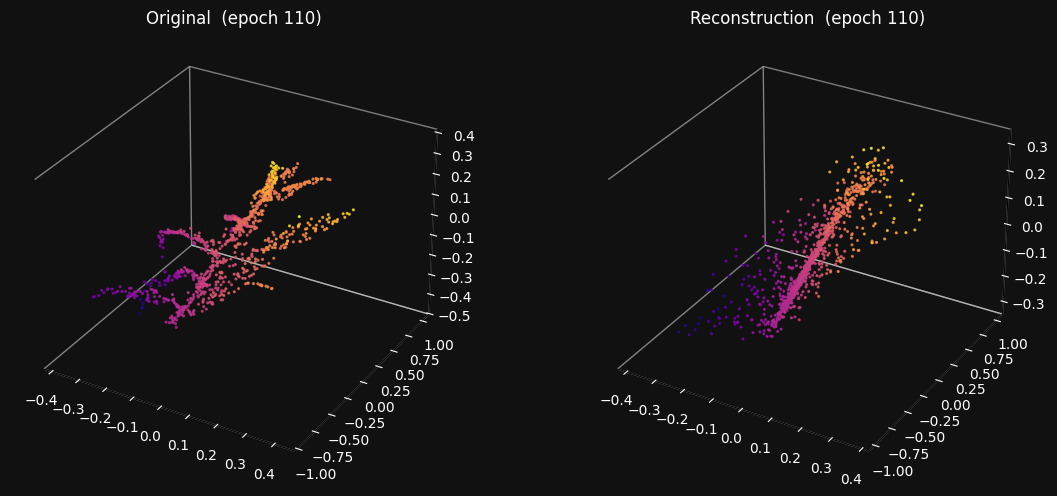

Epoch 111: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 111  train 0.00504  val 0.00555  lr 1.33e-04


Epoch 112: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 112  train 0.00504  val 0.00568  lr 1.30e-04


Epoch 113: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


...

Epoch 118  train 0.00491  val 0.00566  lr 1.16e-04


Epoch 119: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 119  train 0.00480  val 0.00556  lr 1.13e-04


Epoch 120: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 120  train 0.00482  val 0.00549  lr 1.11e-04
  ✅ New best val loss: 0.00549 — saved best_model.pth


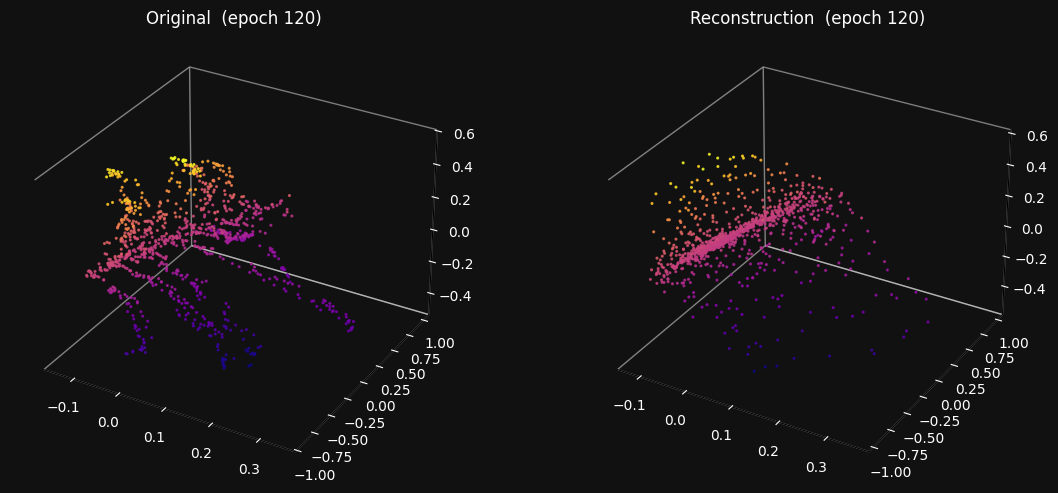

Epoch 121: 100%|██████████| 63/63 [00:24<00:00,  2.57it/s]


Epoch 121  train 0.00477  val 0.00554  lr 1.08e-04


Epoch 122: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 122  train 0.00478  val 0.00569  lr 1.06e-04


Epoch 123: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


...

Epoch 128  train 0.00471  val 0.00542  lr 9.20e-05


Epoch 129: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 129  train 0.00468  val 0.00548  lr 8.97e-05


Epoch 130: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 130  train 0.00459  val 0.00548  lr 8.75e-05


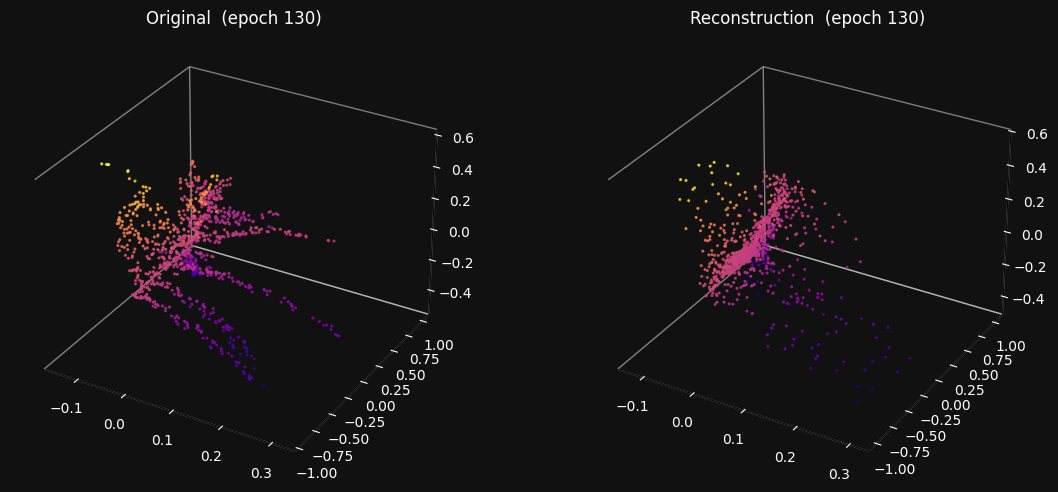

Epoch 131: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 131  train 0.00464  val 0.00535  lr 8.52e-05
  ✅ New best val loss: 0.00535 — saved best_model.pth


Epoch 132: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 132  train 0.00464  val 0.00557  lr 8.30e-05


Epoch 133: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


...

Epoch 138  train 0.00456  val 0.00534  lr 7.00e-05


Epoch 139: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 139  train 0.00450  val 0.00530  lr 6.80e-05
  ✅ New best val loss: 0.00530 — saved best_model.pth


Epoch 140: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 140  train 0.00444  val 0.00532  lr 6.59e-05


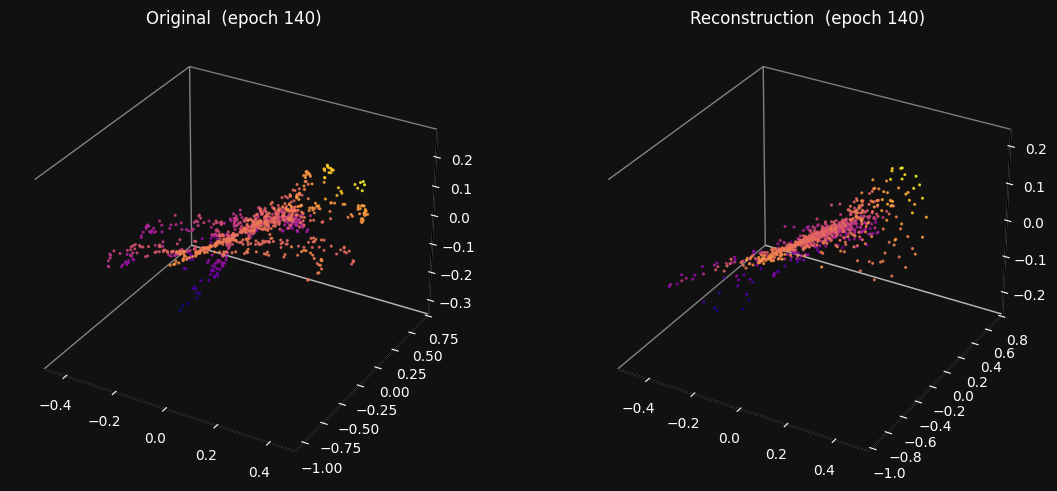

Epoch 141: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 141  train 0.00448  val 0.00536  lr 6.39e-05


Epoch 142: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 142  train 0.00449  val 0.00522  lr 6.18e-05
  ✅ New best val loss: 0.00522 — saved best_model.pth


Epoch 143: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


...

Epoch 148  train 0.00435  val 0.00525  lr 5.02e-05


Epoch 149: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 149  train 0.00440  val 0.00526  lr 4.84e-05


Epoch 150: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 150  train 0.00434  val 0.00528  lr 4.66e-05


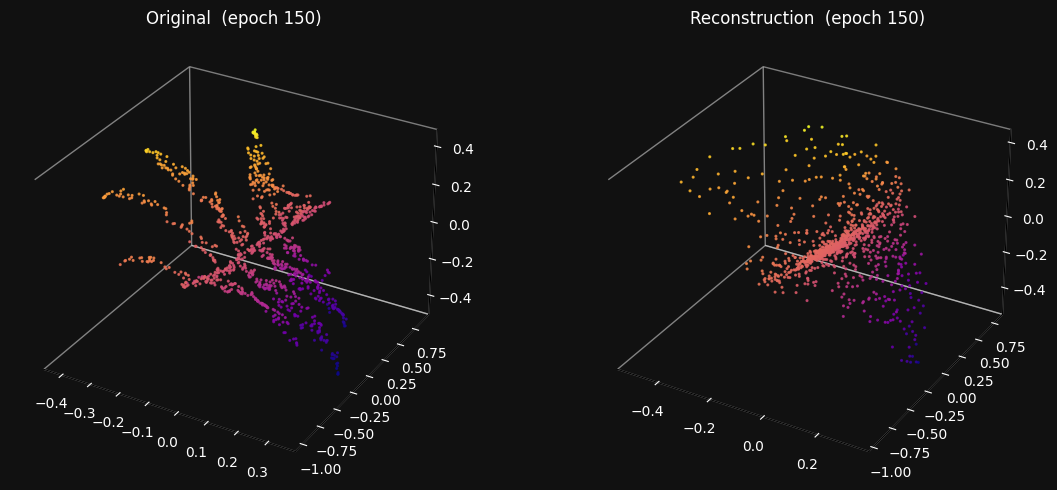

Epoch 151: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 151  train 0.00437  val 0.00521  lr 4.48e-05


Epoch 152: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 152  train 0.00432  val 0.00517  lr 4.31e-05
  ✅ New best val loss: 0.00517 — saved best_model.pth


Epoch 153: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


...

Epoch 158  train 0.00425  val 0.00519  lr 3.32e-05


Epoch 159: 100%|██████████| 63/63 [00:24<00:00,  2.54it/s]


Epoch 159  train 0.00419  val 0.00515  lr 3.16e-05
  ✅ New best val loss: 0.00515 — saved best_model.pth


Epoch 160: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 160  train 0.00418  val 0.00515  lr 3.01e-05


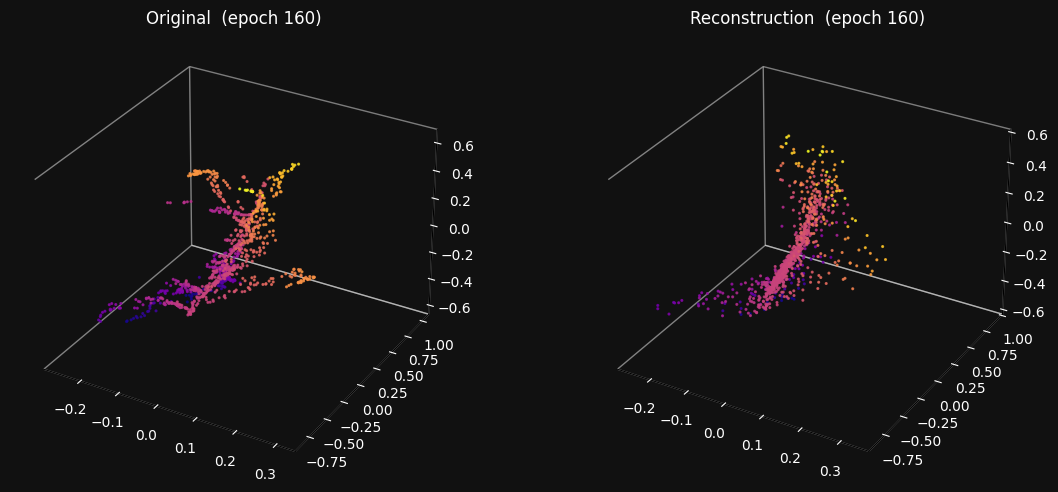

Epoch 161: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 161  train 0.00420  val 0.00517  lr 2.86e-05


Epoch 162: 100%|██████████| 63/63 [00:24<00:00,  2.54it/s]


Epoch 162  train 0.00418  val 0.00520  lr 2.72e-05


Epoch 163: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


...

Epoch 168  train 0.00412  val 0.00510  lr 1.93e-05
  ✅ New best val loss: 0.00510 — saved best_model.pth


Epoch 169: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 169  train 0.00417  val 0.00509  lr 1.81e-05
  ✅ New best val loss: 0.00509 — saved best_model.pth


Epoch 170: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 170  train 0.00413  val 0.00510  lr 1.69e-05


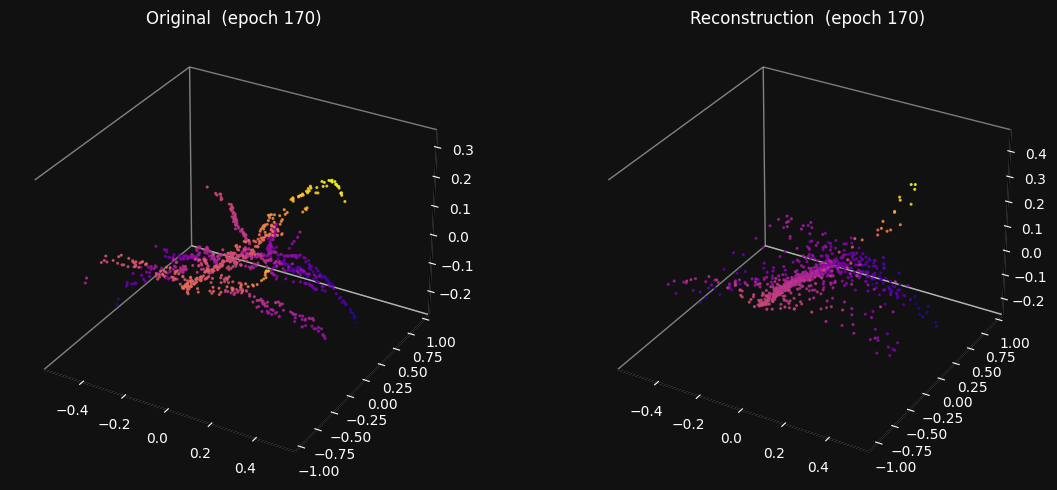

Epoch 171: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


Epoch 171  train 0.00418  val 0.00510  lr 1.58e-05


Epoch 172: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 172  train 0.00414  val 0.00506  lr 1.47e-05
  ✅ New best val loss: 0.00506 — saved best_model.pth


Epoch 173: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


...

Epoch 178  train 0.00405  val 0.00509  lr 8.95e-06


Epoch 179: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 179  train 0.00410  val 0.00509  lr 8.13e-06


Epoch 180: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 180  train 0.00412  val 0.00508  lr 7.34e-06


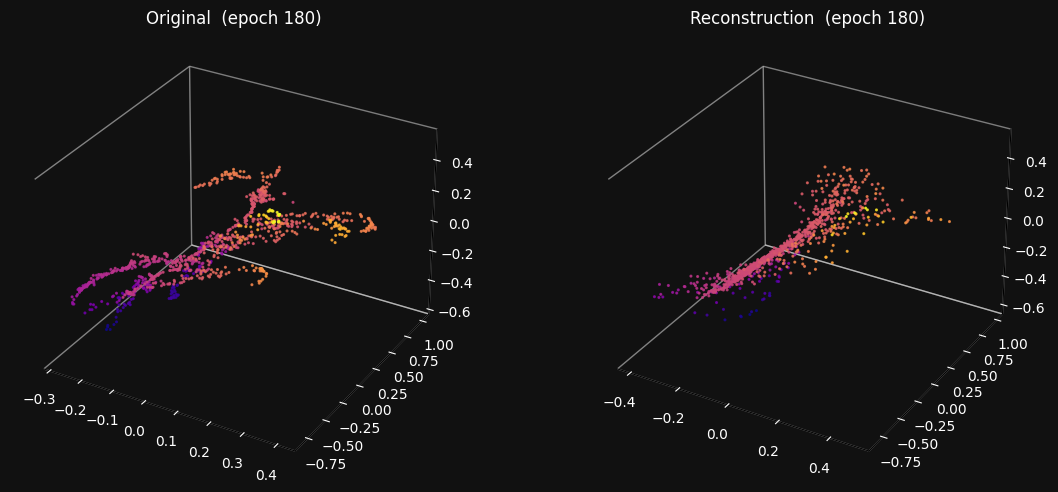

Epoch 181: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 181  train 0.00406  val 0.00510  lr 6.59e-06


Epoch 182: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 182  train 0.00408  val 0.00506  lr 5.89e-06
  ✅ New best val loss: 0.00506 — saved best_model.pth


Epoch 183: 100%|██████████| 63/63 [00:24<00:00,  2.56it/s]


...

Epoch 188  train 0.00404  val 0.00508  lr 2.47e-06


Epoch 189: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 189  train 0.00403  val 0.00507  lr 2.05e-06


Epoch 190: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 190  train 0.00404  val 0.00508  lr 1.66e-06


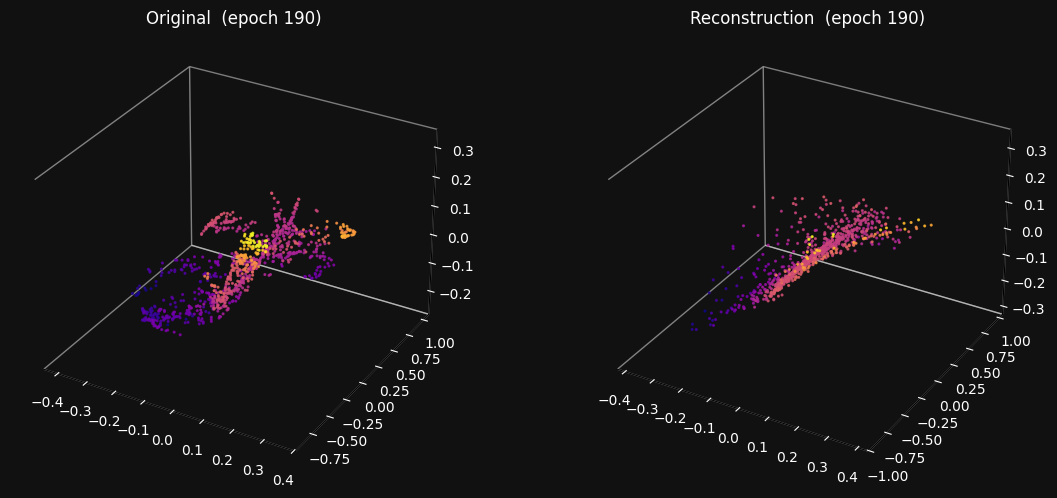

Epoch 191: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 191  train 0.00401  val 0.00506  lr 1.31e-06


Epoch 192: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 192  train 0.00402  val 0.00507  lr 1.00e-06


Epoch 193: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


...

Epoch 197  train 0.00402  val 0.00508  lr 8.20e-08


Epoch 198: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 198  train 0.00401  val 0.00507  lr 2.05e-08


Epoch 199: 100%|██████████| 63/63 [00:24<00:00,  2.55it/s]


Epoch 199  train 0.00406  val 0.00507  lr 0.00e+00


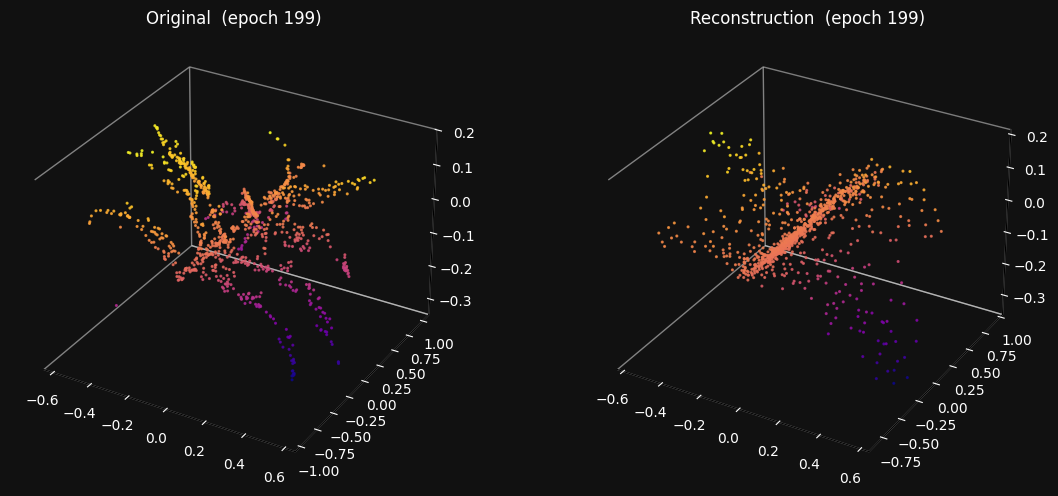

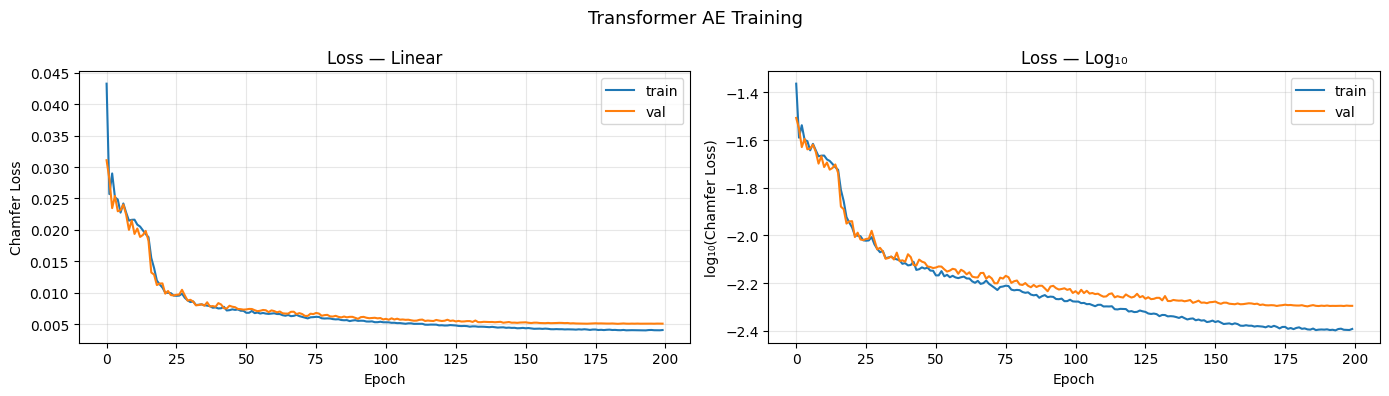

In [ ]:
best_val_loss    = float("inf")
epochs_no_improve = 0
train_loss_history = []
val_loss_history   = []

for epoch in range(CFG["epochs"]):

    # ── train ──────────────────────────────────────────────────────────────
    model.train()
    total_loss = 0.0

    for pc in tqdm(train_loader, desc=f"Epoch {epoch:03d}"):
        pc    = pc.to(DEVICE)
        recon = model(pc)
        loss  = chamfer_loss(pc, recon)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    train_loss = total_loss / len(train_loader)
    val_loss   = evaluate(model, val_loader)
    current_lr = scheduler.get_last_lr()[0]

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    print(f"Epoch {epoch:03d}  train {train_loss:.5f}  val {val_loss:.5f}  lr {current_lr:.2e}")

    # ── W&B log ────────────────────────────────────────────────────────────
    wandb.log({
        "epoch":            epoch,
        "lr":               current_lr,
        "train_loss":       train_loss,
        "val_loss":         val_loss,
        "train_loss_log":   math.log(train_loss) if train_loss > 0 else float("nan"),
        "val_loss_log":     math.log(val_loss)   if val_loss   > 0 else float("nan"),
        "train_val_gap":    train_loss - val_loss,   # watch for overfitting
        "best_val_loss":    best_val_loss,
    })

    # ── best checkpoint ────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  ✅ New best val loss: {best_val_loss:.5f} — saved best_model.pth")
    else:
        epochs_no_improve += 1

    # ── early stopping ─────────────────────────────────────────────────────
    if epochs_no_improve >= CFG["patience"]:
        print(f"⏹ Early stopping at epoch {epoch} (no improvement for {CFG['patience']} epochs)")
        break

    # ── periodic checkpoint + visualization ───────────────────────────────
    if epoch % CFG["checkpoint_interval"] == 0 or epoch == CFG["epochs"] - 1:
        torch.save({
            "epoch":      epoch,
            "model":      model.state_dict(),
            "optimizer":  optimizer.state_dict(),
            "scheduler":  scheduler.state_dict(),
            "best_val":   best_val_loss,
        }, f"checkpoint_epoch_{epoch:03d}.pth")

        fig = visualize_reconstruction(model, val_dataset,
                                       title_suffix=f"  (epoch {epoch})")
        wandb.log({"reconstruction": wandb.Image(fig), "epoch": epoch})
        plt.close(fig)

# ── final loss curve ───────────────────────────────────────────────────────
epochs_ran = range(len(train_loss_history))
fig, axes  = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_ran, train_loss_history, label="train")
axes[0].plot(epochs_ran, val_loss_history,   label="val")
axes[0].set(xlabel="Epoch", ylabel="Chamfer Loss", title="Loss — Linear")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, np.log10(np.maximum(train_loss_history, 1e-9)), label="train")
axes[1].plot(epochs_ran, np.log10(np.maximum(val_loss_history,   1e-9)), label="val")
axes[1].set(xlabel="Epoch", ylabel="log₁₀(Chamfer Loss)", title="Loss — Log₁₀")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Transformer AE Training", fontsize=13)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Test evaluation

In [ ]:
# Load best weights for test evaluation
model.load_state_dict(torch.load("best_model.pth"))

test_loss = evaluate(model, test_loader)
print(f"Test Chamfer: {test_loss:.5f}")

wandb.log({
    "test_loss":     test_loss,
    "test_loss_log": math.log(test_loss) if test_loss > 0 else float("nan"),
})

Test Chamfer: 0.00484


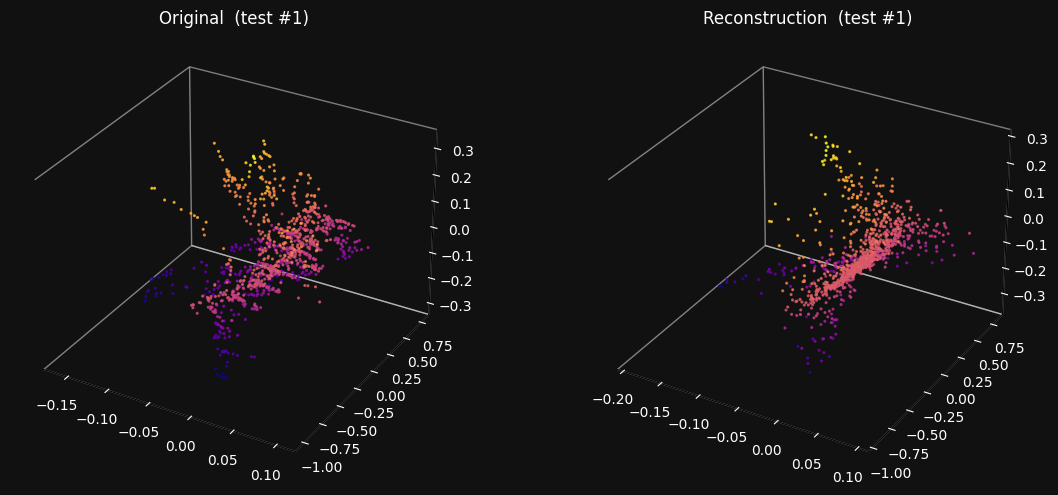

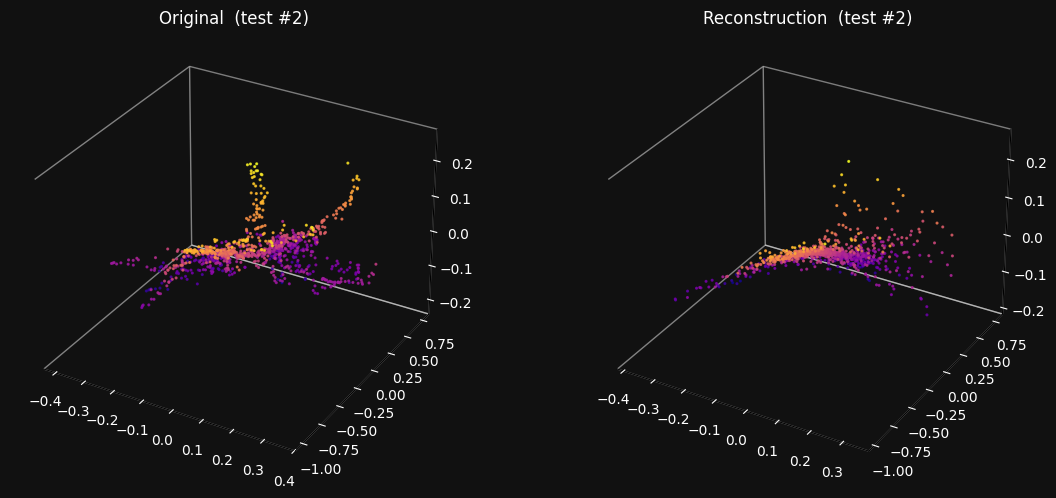

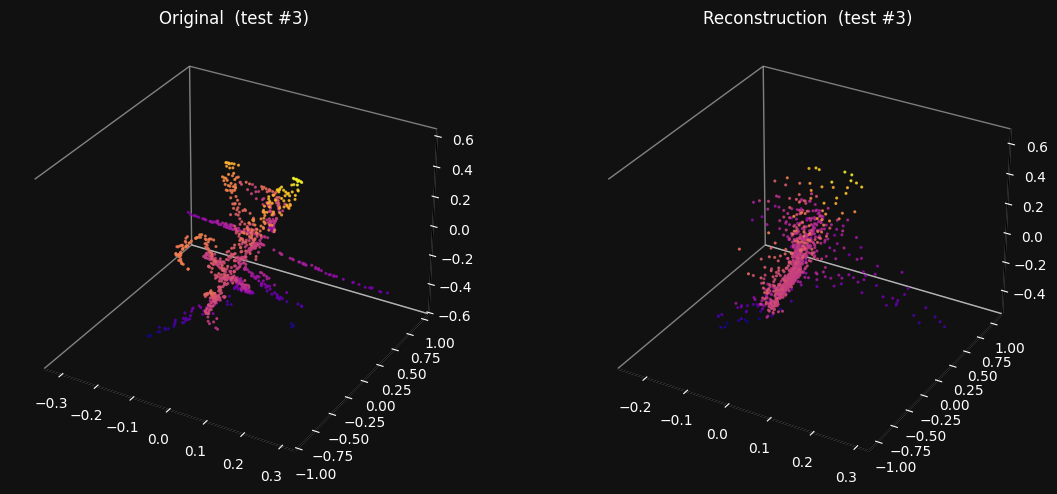

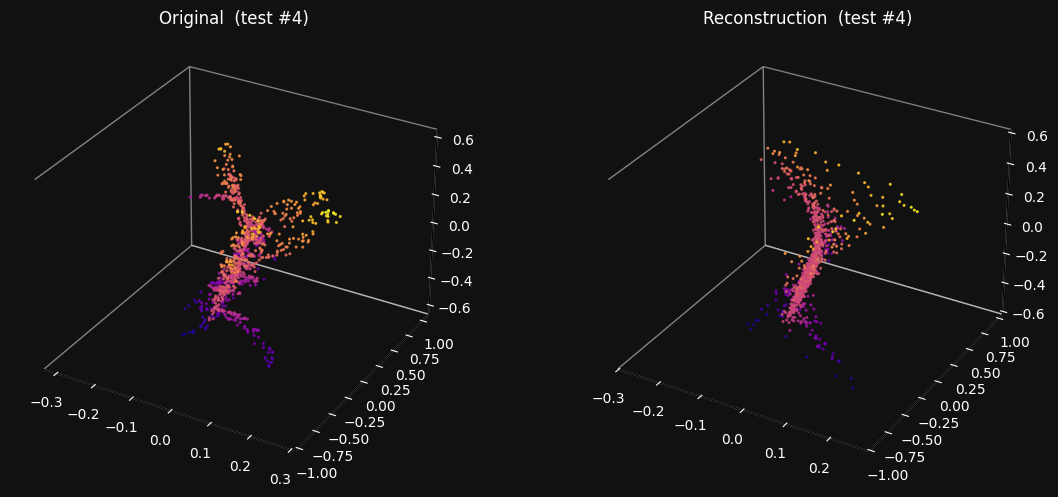

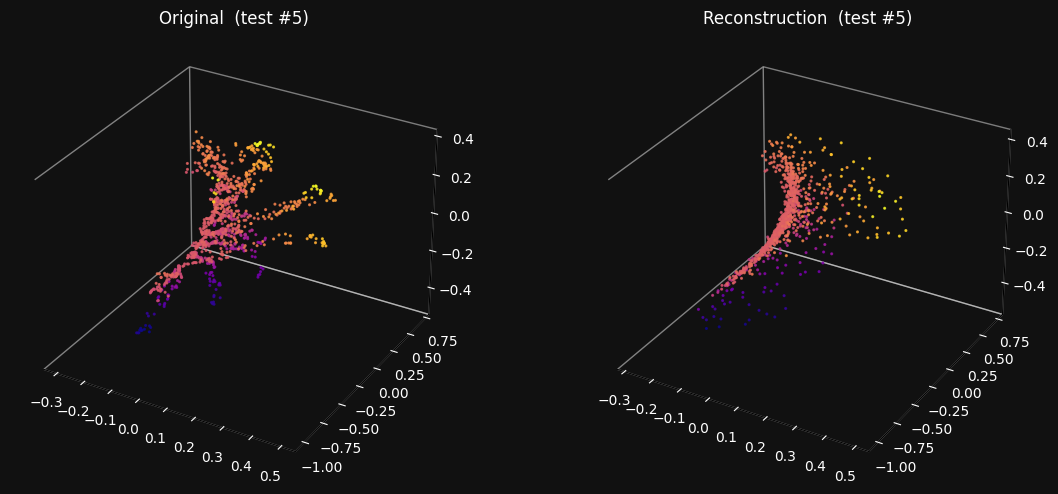

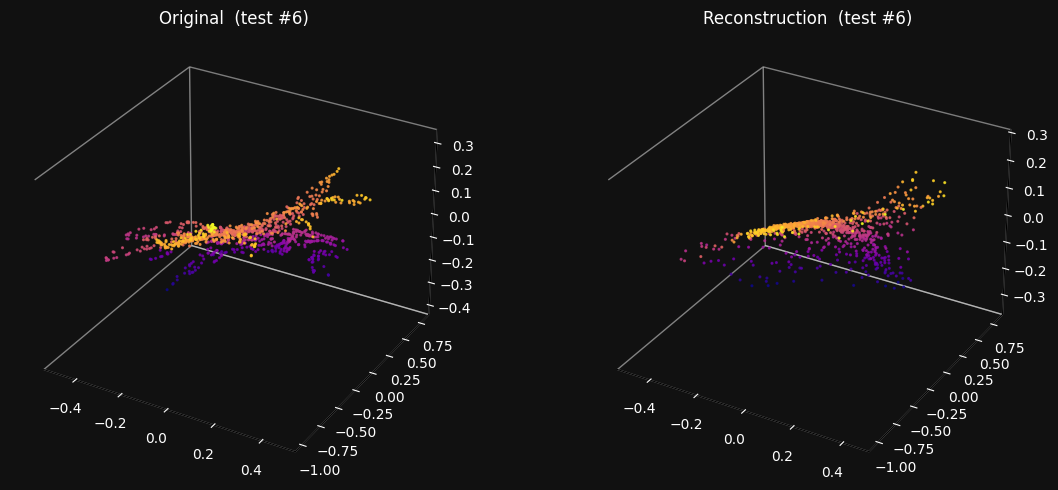

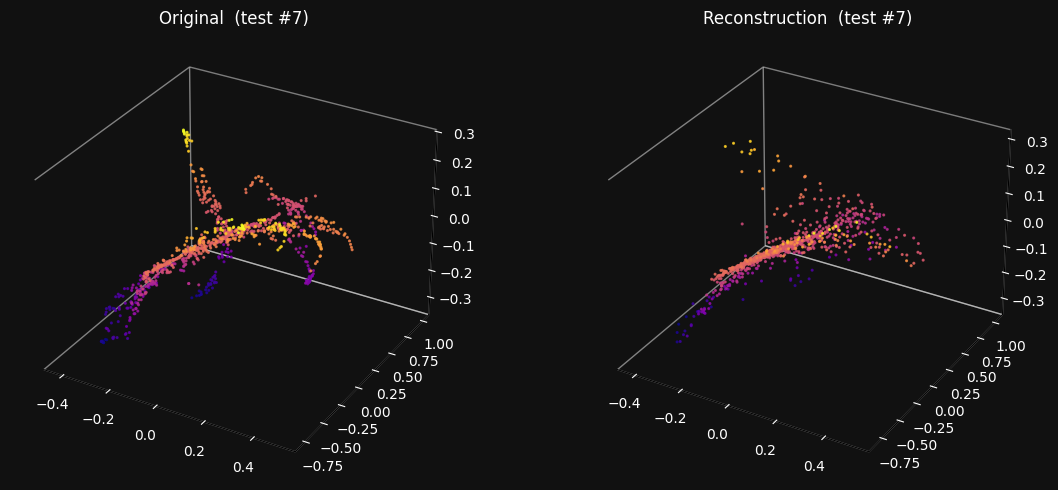

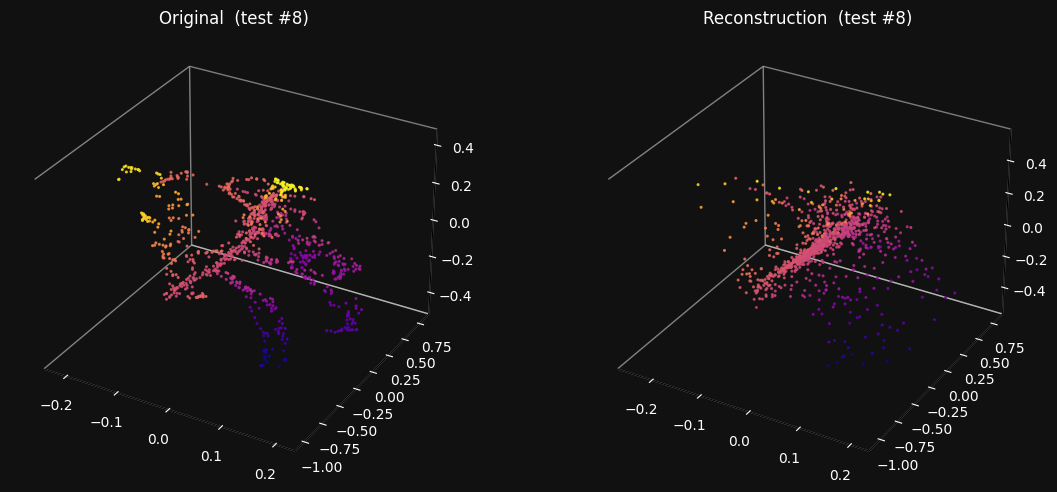

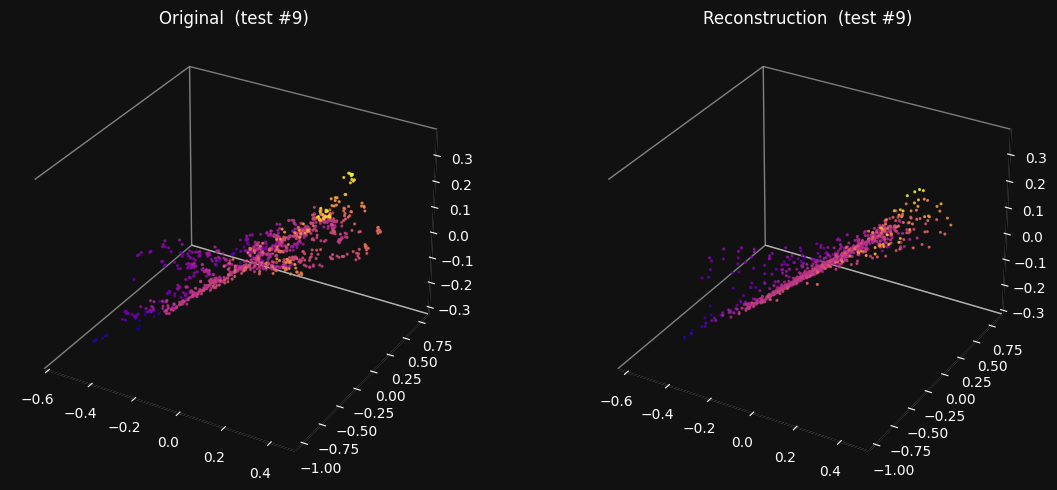

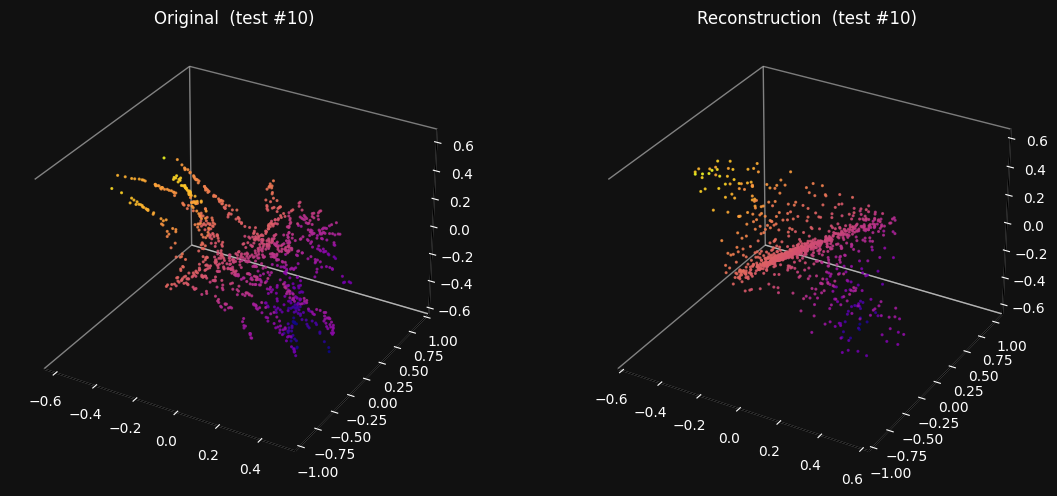

In [ ]:
for i in range(10):
    fig = visualize_reconstruction(model, test_dataset, title_suffix=f"  (test #{i+1})")
    wandb.log({"test_reconstruction": wandb.Image(fig)})
    plt.close(fig)

In [ ]:
wandb.finish()

best_val_loss,███▆▆▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▆▆▆▇▇▇██████
lr,▄▅██████▇▇▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▄▄▄▄▃▂▂▂▂▁▁▁▁▁▁
test_loss,▁
test_loss_log,▁
train_loss,██▇█▆▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_log,█████▇▇▆▅▅▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_val_gap,▁▇██▅▇▇▇▆▆▆▇▇▇▇▇▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
val_loss,█▆▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss_log,██▇▅▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_loss,0.00548
